In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from itertools import combinations
work_dir = '/Users/oskarsvensson/Science/FILES/ARTICLES/Hst1_self/Hst1_self_asso/analysis/dimer/res-res/'

cm = 1/2.54
font = 8
font_label = 10
plt.rcParams['font.family'] = 'Helvetica'

colors = ['darkblue', 'aquamarine', 'darkorange']
cmap = LinearSegmentedColormap.from_list('mycmap', colors)
amount = 100
color_list = cmap(np.linspace(0, 1, amount))

In [40]:
sequence = 'DSHEKRHHGYRRKFHEKHHSHREFPFYGDYGSNYLYDN'
amino_acid_codes = 'ARNDCQEGHILKMFPSTWYV'
residues = sequence*4
residue_index = {}
bonds = []
bond_types = []

counter = 0
for letter in residues:
    residue_index[counter] = letter
    counter += 1

pairs = list(combinations(residue_index, 2))
for pair in pairs:
    counter = 0
    for code in amino_acid_codes:
        if residue_index[pair[0]] == code:
            pos1 = counter
        elif residue_index[pair[1]] == code:
            pos2 = counter
        counter += 1
    if pos1 < pos2:
        bonds.append(residue_index[pair[0]] + residue_index[pair[1]])
    elif pos2 < pos1:
        bonds.append(residue_index[pair[1]] + residue_index[pair[0]])

for bond in bonds:
    if bond not in bond_types:
        bond_types.append(bond)

In [44]:
max_value = 0
min_value = 10

for pair in pairs:
    temp_array = np.genfromtxt((work_dir + 'Res' + str(pair[0]) + '/' + str(pair[0]) + '_' + str(pair[1]) + '.xvg'), 
                               usecols=(1), unpack=True, skip_header=24)
    if (np.absolute(pair[0] - pair[1]) <= 37):
        continue
    else:
        for temp in (temp_array*10):
            if temp > max_value:
                max_value = int(temp)
            elif temp < min_value:
                min_value = int(temp)

dist_range = range(min_value, (max_value + 1), 1)
dist_array = np.zeros((len(bond_types), len(dist_range)))

In [49]:
counter = 0
for array in dist_array:
    for (pair, bond) in zip(pairs, bonds):
        if np.absolute(pair[0] - pair[1]) <= 37:
            continue
        elif bond == bond_types[counter]:
            dataset = np.genfromtxt((work_dir + 'Res' + str(pair[0]) + '/' + str(pair[0]) + '_' + str(pair[1]) + '.xvg'), 
                                    usecols=(1), unpack=True, skip_header=24)
            position = 0
            for nr in dist_range:
                for point in (dataset*10):
                    if int(point) == nr:
                        array[position] += 1
                position += 1 
    print('Array Nr ' + str(counter) + ' Done')
    counter += 1

Array Nr 0 Done
Array Nr 1 Done
Array Nr 2 Done
Array Nr 3 Done
Array Nr 4 Done
Array Nr 5 Done
Array Nr 6 Done
Array Nr 7 Done
Array Nr 8 Done
Array Nr 9 Done
Array Nr 10 Done
Array Nr 11 Done
Array Nr 12 Done
Array Nr 13 Done
Array Nr 14 Done
Array Nr 15 Done
Array Nr 16 Done
Array Nr 17 Done
Array Nr 18 Done
Array Nr 19 Done
Array Nr 20 Done
Array Nr 21 Done
Array Nr 22 Done
Array Nr 23 Done
Array Nr 24 Done
Array Nr 25 Done
Array Nr 26 Done
Array Nr 27 Done
Array Nr 28 Done
Array Nr 29 Done
Array Nr 30 Done
Array Nr 31 Done
Array Nr 32 Done
Array Nr 33 Done
Array Nr 34 Done
Array Nr 35 Done
Array Nr 36 Done
Array Nr 37 Done
Array Nr 38 Done
Array Nr 39 Done
Array Nr 40 Done
Array Nr 41 Done
Array Nr 42 Done
Array Nr 43 Done
Array Nr 44 Done
Array Nr 45 Done
Array Nr 46 Done
Array Nr 47 Done
Array Nr 48 Done
Array Nr 49 Done
Array Nr 50 Done
Array Nr 51 Done
Array Nr 52 Done
Array Nr 53 Done
Array Nr 54 Done
Array Nr 55 Done
Array Nr 56 Done
Array Nr 57 Done
Array Nr 58 Done
Array N

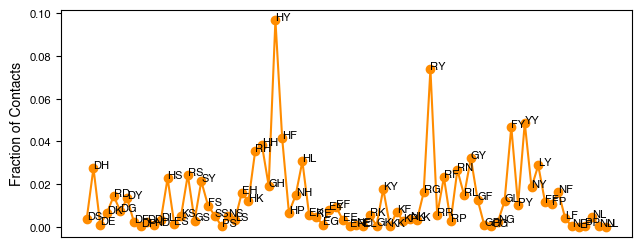

In [94]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=((16*cm), (6*cm)), layout='constrained')
contact_counts = []
for array in dist_array:
    contact_counts.append(array[1])
ax.plot(bond_types, (contact_counts/sum(contact_counts)), color=color_list[-1])

counter = 0
for point in contact_counts:
    ax.scatter(bond_types[counter], (point/sum(contact_counts)), color=color_list[-1])
    ax.text(bond_types[counter], (point/sum(contact_counts)), str(bond_types[counter]), fontsize=font)
    counter += 1
    
ax.tick_params(labelsize=font)
ax.set_xticks([])
ax.set_ylabel('Fraction of Contacts', fontsize=font_label)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/Contact_counts.pdf', dpi=1000)

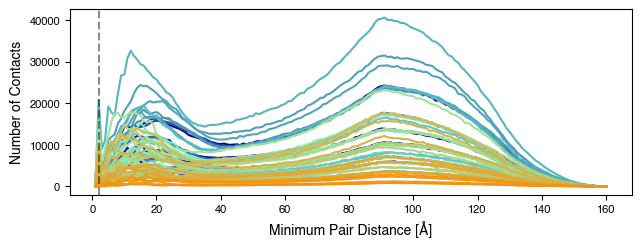

In [117]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=((16*cm), (6*cm)), layout='constrained')
color_pick = 0
for array in dist_array:
    ax.plot(dist_range, array, color=color_list[int(color_pick)])
    color_pick += 1.25
ax.axvline(2, linestyle='--', alpha=0.45, color='black')
ax.tick_params(labelsize=font)
ax.set_xlabel('Minimum Pair Distance [Å]', fontsize=font_label)
ax.set_ylabel('Number of Contacts', fontsize=font_label)
plt.savefig('/Users/oskarsvensson/Desktop/Current/Hst1_asso/New_new_figures/Full_pairdist_disti.pdf', dpi=1000)